# Attribution Explorer — BioS birthday recall

Step through people, see what the model predicts, then trace the date-recall circuit with circuit-tracer on the trained `grid-L4-H6` CLT. Section 8 (**Feature Explorer**) sweeps the CLT features that fire when the model recalls a given birth **month** across many people.

**Run order:** cells 1–3 once (setup, people, **load model**). Then per person: set `PERSON_IDX` in cell 4, run **4** (prompt + prediction) → **5** (build) → **6** (chart), and view in **7** (server stays up across rebuilds). Section **8** is independent — it only needs cells 1–3.

> Kernel must be the `clts/.venv-ct` interpreter.

## 1 · Setup

In [13]:
import re
import sys
from pathlib import Path

# The notebook lives in clts/; run everything relative to the repo root.
REPO = Path.cwd()
if REPO.name == "clts":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

# Fixed inputs — only one trained CLT exists.
MODEL_DIR = REPO / "model/grid-L4-H6"
CLT_DIR   = REPO / "clts/clt_runs/grid-L4-H6/mult16_l02_lr0.0001_ep50_n10000/final"
DATA_DIR  = REPO / "data/bioS_N-Bd_final_grid"
SCAN_NAME = "grid-L4-H6"
DEVICE    = "cpu"

from clts.storage import storage_root
from util.condensed_tokenizer import CondensedTokenizer

# All explored prompts accumulate in ONE shared dir, so the viewer's dropdown
# lists them together (graph-metadata.json is merged across builds).
GRAPH_DIR = storage_root() / "clt_graphs" / SCAN_NAME / "explore"

# Used to skip people whose name has out-of-vocab subwords (same check the
# CLI's default_birthday_prompt uses).
ct = CondensedTokenizer.from_remap_path(DATA_DIR / "old_to_new.json")

def name_in_vocab(name: str) -> bool:
    try:
        ct.encode(name)
        return True
    except KeyError:
        return False

print("repo        :", REPO)
print("storage_root:", storage_root())
print("graph dir   :", GRAPH_DIR)
assert MODEL_DIR.exists() and CLT_DIR.exists() and DATA_DIR.exists(), "check the fixed paths above"

repo        : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4
storage_root: /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage
graph dir   : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_graphs/grid-L4-H6/explore


## 2 · Load people

In [23]:
import pandas as pd

from util.bio_sampler import BioSampler

sampler = BioSampler(DATA_DIR / "people.json", fields=("birthday",))
print(f"{len(sampler.people):,} people loaded")
pd.DataFrame(sampler.people[:5])

50,000 people loaded


,id,first_name,middle_name,last_name,birthday,birthmonth,birthyear,birthcity,university,field,company1name,company1city
0,1,Gabriella,Ella,Rigby,18,February,1816,"Long Beach, CA",Oregon State University,Business Analytics,Hyatt,"Chicago, IL"
1,3,Nevaeh,Alice,Kay,10,June,1859,"Durham, NC","Texas A&M University, College Station",Technology Management,UnitedHealth Group,"Minnetonka, MN"
2,4,Logan,Colton,Doherty,17,July,1741,"Fresno, CA",Boston University,Engineering,General Motors,"Detroit, MI"
3,6,Cesar,Vincent,Kumar,22,February,1850,"Albuquerque, NM",Augusta University,Botany,NextEra Energy,"Juno Beach, FL"
4,9,Ashlyn,Nevaeh,Poole,22,November,1716,"Des Moines, IA",George Washington University,Business Analytics,Forever 21,"Los Angeles, CA"


## 3 · Load the replacement model

Loads the circuit-tracer replacement model (custom Llama + trained CLT) **once** and caches it in `model`. Reused for the per-person prediction (cell 4) and the Feature Explorer (section 8). Re-running is a no-op; set `model = None` and re-run to force a reload.

> First load takes ~10 s on CPU.

In [ ]:
from clts.export_tokenizer import ensure_hf_tokenizer
from clts.load_replacement_model import load_replacement_model

# Load once and cache in the kernel. The same `model` powers the prediction in
# cell 4 and the feature sweep in section 8. Set `model = None` + re-run to reload.
if globals().get("model") is None:
    _hf_tok = ensure_hf_tokenizer(DATA_DIR)
    model = load_replacement_model(MODEL_DIR, CLT_DIR, _hf_tok, SCAN_NAME, device=DEVICE)
    print(f"loaded replacement model — n_layers={model.cfg.n_layers}, "
          f"d_model={model.cfg.d_model}, d_vocab={model.cfg.d_vocab}, "
          f"scan={getattr(model, 'scan', SCAN_NAME)!r}")
else:
    print("model already loaded (set `model = None` and re-run to reload)")

## 4 · Pick a person — build the prompt & see the prediction  *(bump `PERSON_IDX` to step through people)*

Builds an **exact training-distribution prefix** (full name, leading space, cut right before the target field) so recall isn't broken by off-distribution wording, then runs `model` on it and prints the top next-token predictions (with the target's probability and rank). Knobs:

- **`PERSON_IDX`** — stable 0-based index over people whose names tokenize cleanly (`0, 1, 2, …`).
- **`FIELD`** — `"MONTH"` cuts right before the birth month (prompt ends `…was born on`, target = the month); `"DATE"` cuts before the day (prompt ends `…on August`, target = the day number).
- **`RANDOM_TEMPLATE`** — `False` → plain `"<name> was born on"` (template 0); `True` → a random one of the birthday paraphrases.
- **`CUSTOM_PROMPT`** — set a string to trace anything directly (overrides the above; `target` falls back to the top predicted token).

The `slug` comes from the prompt, so each distinct phrasing is its own graph in the viewer dropdown.

In [ ]:
import random
import torch

PERSON_IDX = 0           # which person: 0, 1, 2, ... (stable over in-vocab people)
FIELD = "MONTH"          # "MONTH" -> predict birth month; "DATE" -> predict the day
RANDOM_TEMPLATE = False  # True -> random birthday paraphrase; False -> plain "was born on"
CUSTOM_PROMPT = None     # set a string to trace YOUR prompt (overrides the above)

if CUSTOM_PROMPT:
    prompt = CUSTOM_PROMPT
    person = None
    target = None
    print("Custom prompt:", repr(prompt))
else:
    # Walk people in order; count only those whose name tokenizes cleanly, so
    # PERSON_IDX is a stable 0-based index over usable people.
    person = None
    count = 0
    for p in sampler.people:
        nm = f"{p['first_name']} {p['last_name']}"
        if name_in_vocab(nm):
            if count == PERSON_IDX:
                person = p
                break
            count += 1
    if person is None:
        raise IndexError(f"PERSON_IDX={PERSON_IDX} is past the last in-vocab person")

    full_name = f"{person['first_name']} {person['middle_name']} {person['last_name']}"
    # Render the bio with the chosen template, then cut it to an EXACT training
    # prefix (leading space, full name). Template 0 is "<name> was born on";
    # RANDOM_TEMPLATE picks one of the paraphrases.
    exposure_idx = random.randrange(sampler.n_templates) if RANDOM_TEMPLATE else 0
    bio = sampler.render(person, exposure_idx)
    full_date = f"{person['birthmonth']} {person['birthday']}, {person['birthyear']}"
    if FIELD == "MONTH":
        prompt = bio[:bio.index(full_date)].rstrip()      # ends "...was born on"
        target = f" {person['birthmonth']}"                # the month (single token)
    elif FIELD == "DATE":
        day_part = f"{person['birthday']}, {person['birthyear']}"
        prompt = bio[:bio.index(day_part)].rstrip()        # ends "...on August"
        target = f" {person['birthday']}"                  # the day number
    else:
        raise ValueError(f"FIELD must be 'MONTH' or 'DATE', got {FIELD!r}")

    print(f"Person #{PERSON_IDX}: {full_name}  (template #{exposure_idx}, FIELD={FIELD})")
    for k in ("birthday", "birthmonth", "birthyear", "birthcity", "university", "field"):
        if k in person:
            print(f"  {k:11s}: {person[k]}")
    print("\nFull bio:\n ", repr(bio))

slug = re.sub(r"[^a-z0-9]+", "-", prompt.lower()).strip("-")[:60] or "graph"
print("\nPrompt to trace :", repr(prompt))
print("Target token    :", repr(target))
print("Slug            :", slug)

# --- run the model on the prompt to see what it predicts ---------------------
tokens = model.ensure_tokenized(prompt)
with torch.inference_mode():
    logits = model(tokens.unsqueeze(0))
probs = logits[0, -1].softmax(-1)

target_id = None
if target is not None:
    _tids = model.tokenizer.encode(target, add_special_tokens=False)
    target_id = _tids[0] if len(_tids) == 1 else None

TOPK = 10
top_p, top_i = probs.topk(TOPK)
print(f"\nModel prediction — top {TOPK} next tokens:")
for rank, (pi, pp) in enumerate(zip(top_i.tolist(), top_p.tolist()), 1):
    mark = "  <- target" if (target_id is not None and pi == target_id) else ""
    print(f"  {rank:>2}. {model.tokenizer.decode([pi])!r:<14} p={pp:.3f}{mark}")

# Report where the target landed; if a CUSTOM_PROMPT gave no target, default it
# to the top prediction so cell 5 still has something to attribute toward.
if target is None:
    target = model.tokenizer.decode([int(top_i[0])])
    print(f"\nNo target set — defaulting to top prediction {target!r}")
elif target_id is not None:
    tgt_rank = int((probs > probs[target_id]).sum()) + 1
    print(f"\nTarget {target!r}: p={probs[target_id]:.3f}, rank {tgt_rank}/{probs.numel()}")
else:
    print(f"\nTarget {target!r} is not a single token; left as-is for attribution.")

## 5 · Build the attribution graph

Runs circuit-tracer's `attribute()` (via `build_graph`) toward `target` (the field chosen in cell 4) and writes the viewer files + fidelity report into the shared `clt_graphs/grid-L4-H6/explore/` dir (one `<slug>.json` per prompt).

In [30]:
import importlib

import clts.build_attribution_graph as _bag
importlib.reload(_bag)   # pick up edits to build_attribution_graph.py without a kernel restart

result = _bag.build_graph(
    model_dir=MODEL_DIR,
    clt_dir=CLT_DIR,
    data_dir=DATA_DIR,
    scan_name=SCAN_NAME,
    graph_dir=GRAPH_DIR,
    slug=slug,
    prompt=prompt,
    target=target,
    device=DEVICE,
    verbose=False,
)
graph  = result["graph"]
report = result["report"]

# Tell me whether I'm reopening an arranged graph or starting fresh.
# (.get(...) keeps this working even if an older build_graph is still cached.)
status = result.get("status", "rebuilt")
lc = result.get("layout_counts", {"pins": 0, "supernodes": 0, "renames": 0})
if status == "new":
    print(f"🆕 NEW graph '{slug}' — no prior version existed.")
elif status == "reused":
    print(f"📂 REOPENED saved graph '{slug}' — your layout is restored "
          f"({lc['pins']} pins, {lc['supernodes']} groups, {lc['renames']} renames). "
          f"Hard-refresh the viewer to see it.")
elif status == "inputs-changed":
    print(f"⚠️  '{slug}' existed but the build inputs CHANGED — fresh graph. "
          f"Your old layout was backed up to {slug}.qparams-backup.json (not applied).")
else:  # rebuilt
    print(f"🔁 Rebuilt existing graph '{slug}' (no saved layout yet).")
print(f"wrote {slug}.json → {GRAPH_DIR}")
report


[tokenizer] cache hit: /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/hf_tokenizers/0518e632
Moving model to device:  cpu


/Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clts/.venv-ct/lib/python3.11/site-packages/circuit_tracer/attribution/context_transformerlens.py:223: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  self._resid_activations[last_layer].backward(


🔁 Rebuilt existing graph 'gage-wyatt-clay-was-born-on-the-memorable-date-of' (no saved layout yet).
wrote gage-wyatt-clay-was-born-on-the-memorable-date-of.json → /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_graphs/grid-L4-H6/explore


{'prompt': ' Gage Wyatt Clay was born on the memorable date of',
 'scan_name': 'grid-L4-H6',
 'top_logit_token': ' August',
 'target_logit_prob': 1.0,
 'replacement_score': 0.5426021218299866,
 'completeness_score': 0.8815776705741882,
 'error_influence_share': 0.4573978781700134,
 'n_feature_nodes_after_pruning': 555}

## 6 · Inline visualization — top feature nodes

Per-node influence on the target logit (circuit-tracer's own `compute_node_influence`), restricted to feature nodes and ranked. The full node-link graph is in the web viewer (cell 7).

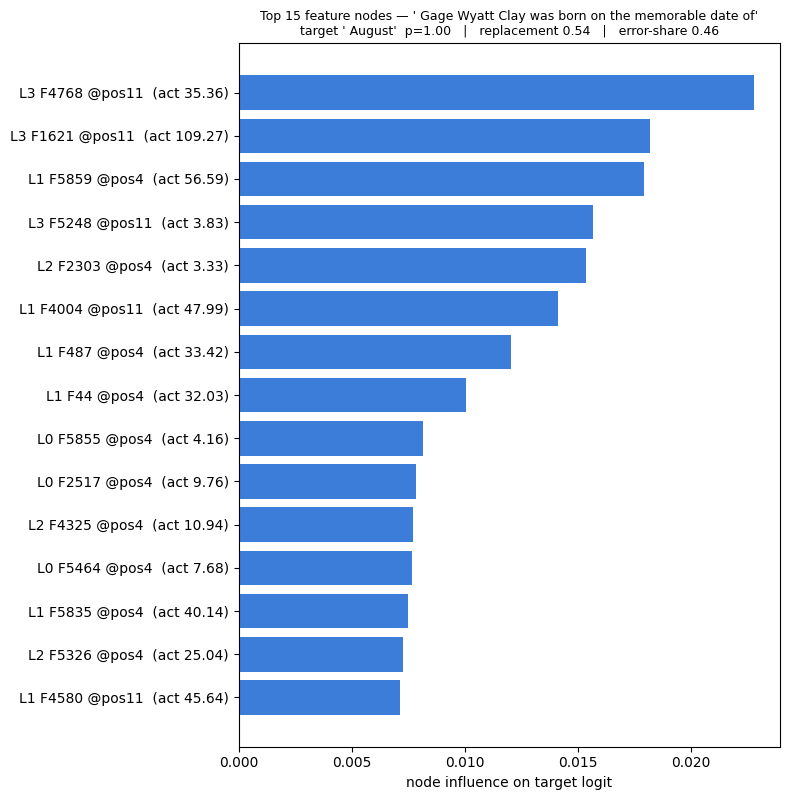

In [31]:
import matplotlib.pyplot as plt
import torch

from circuit_tracer.graph import compute_node_influence

TOP_K = 15

A = graph.adjacency_matrix.cpu()
n_logits   = len(graph.logit_targets)
n_features = len(graph.selected_features)

# logit_weights: weight only the logit nodes (last n_logits), as prune_graph does.
logit_weights = torch.zeros(A.shape[0])
logit_weights[-n_logits:] = graph.logit_probabilities.cpu()
node_influence = compute_node_influence(A, logit_weights)

feat_infl = node_influence[:n_features]
order = torch.argsort(feat_infl, descending=True)[:TOP_K]

labels, vals = [], []
for i in order.tolist():
    layer, pos, fidx = graph.active_features[graph.selected_features[i]].tolist()
    act = graph.activation_values[i].item()
    labels.append(f"L{layer} F{fidx} @pos{pos}  (act {act:.2f})")
    vals.append(feat_infl[i].item())

fig, ax = plt.subplots(figsize=(8, 0.42 * len(labels) + 1.8))
ax.barh(range(len(labels)), vals, color="#3b7dd8")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("node influence on target logit")
ax.set_title(
    f"Top {len(labels)} feature nodes — {report['prompt']!r}\n"
    f"target {report['top_logit_token']!r}  p={report['target_logit_prob']:.2f}   |   "
    f"replacement {report['replacement_score']:.2f}   |   "
    f"error-share {report['error_influence_share']:.2f}",
    fontsize=9,
)
plt.tight_layout()
plt.show()

## 7 · Launch the web viewer

Serves circuit-tracer's interactive viewer for the shared `explore/` folder (in-process). **Run this once** — it stays up across rebuilds. After re-running cells 4–5 for a new prompt, either open the printed `?slug=` link or pick the prompt from the **dropdown at the top of the viewer**. Call `server.stop()` to shut down.

In [ ]:
from clts.serve_ui import start_server

features_dir = storage_root() / "clt_features" / SCAN_NAME

# Reuse one server across rebuilds; stop a stale one first so the port isn't
# left held by an old graph folder (which would keep showing the old graph).
try:
    server.stop()
except NameError:
    pass
server = start_server(str(GRAPH_DIR), str(features_dir), SCAN_NAME, port=8032)

print(f"Viewer → http://localhost:8032/?slug={slug}")
print("That link loads THIS prompt's graph directly.")
print("For another prompt: re-run cells 4–5, then open its printed ?slug= link")
print("or switch via the dropdown at the top of the viewer (no restart needed).")
print("server.stop()  # to shut down")

## 8 · Feature Explorer — which CLT features recall a birth month

The CLT analog of the SAE "features that fire on token X" sweep. For each month, take people born in that month, build the recall prompt (`…was born on`, template 0), run the model, and read the CLT feature activations **at the recall position** (the last token, where the month is predicted). Aggregate across people to get each feature's mean activation per month, then rank by:

- **`mean_target`** — how hard a feature fires on this month's recall positions, and
- **`specificity = mean_target / mean_other`** — how selectively it fires on this month vs. a shared baseline of all *other* months.

Features are identified as `L{layer} F{idx}` — the same scheme as the attribution chart (cell 6) and the web viewer (cell 7), so a feature you find here can be looked up there. Needs cells 1–3 (reuses the loaded `model`).

### 8a · Sweep — gather recall features per month

Runs `~N_PER_MONTH` people through each of the twelve months and accumulates the per-feature activation sum. Cached to `clt_storage/clt_feature_explorer/<scan>/` — set `RECOMPUTE = True` (or bump `N_PER_MONTH`) to re-run. ~minutes on CPU for the first build; instant once cached.

In [ ]:
import torch
from collections import defaultdict

MONTH_STRINGS = [
    "January", "February", "March",     "April",   "May",      "June",
    "July",    "August",   "September", "October", "November", "December",
]

# In-vocab people grouped by birth month (same name filter cell 4 uses). Order
# follows people.json, so the per-month sample below is deterministic.
people_by_month = defaultdict(list)
for p in sampler.people:
    nm = f"{p['first_name']} {p['last_name']}"
    if name_in_vocab(nm):
        people_by_month[p["birthmonth"]].append(p)

print("in-vocab people per month:")
for m in MONTH_STRINGS:
    print(f"  {m:>10}: {len(people_by_month[m]):>5}")


def recall_prompt(person, exposure_idx=0):
    """Training-prefix prompt ending right before the birth month, so the next
    token the model predicts is the month (template 0 = '<name> was born on')."""
    bio = sampler.render(person, exposure_idx)
    full_date = f"{person['birthmonth']} {person['birthday']}, {person['birthyear']}"
    return bio[:bio.index(full_date)].rstrip()


@torch.no_grad()
def recall_features(prompt):
    """CLT feature activations at the recall position (the last token).

    get_activations returns [n_layers, seq, d_transcoder]; position 0 (BOS) is
    already zeroed by the model. We take the final position — the moment the
    month is recalled. Returns [n_layers, d_transcoder]."""
    _logits, cache = model.get_activations(prompt)
    return cache[:, -1, :].clone()

In [ ]:
import time

N_PER_MONTH = 200    # people sampled per month (CPU inference cost scales with this)
RECOMPUTE = False    # set True to ignore the cache and re-run the sweep

CACHE_DIR = storage_root() / "clt_feature_explorer" / SCAN_NAME
CACHE_PATH = CACHE_DIR / f"recall_month_sums_n{N_PER_MONTH}.pt"

if CACHE_PATH.exists() and not RECOMPUTE:
    blob = torch.load(CACHE_PATH, weights_only=False)
    month_sum, month_cnt = blob["sum"], blob["count"]
    print(f"loaded cached sweep from {CACHE_PATH}")
else:
    # Per month: running sum of the [n_layers, d_transcoder] recall-position
    # activation across the sampled people, plus how many people contributed.
    month_sum, month_cnt = {}, {}
    t0 = time.time()
    for m in MONTH_STRINGS:
        people = people_by_month[m][:N_PER_MONTH]
        s = None
        for p in people:
            feats = recall_features(recall_prompt(p))     # [n_layers, d_transcoder]
            s = feats.clone() if s is None else s + feats
        month_sum[m] = s
        month_cnt[m] = len(people)
        print(f"  {m:>10}: {len(people):>4} people  ({time.time() - t0:5.1f}s elapsed)")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({"sum": month_sum, "count": month_cnt}, CACHE_PATH)
    print(f"wrote {CACHE_PATH}")

# Totals across all months -> the 'other' baseline for any single month.
total_sum = sum(month_sum[m] for m in MONTH_STRINGS)
total_cnt = sum(month_cnt[m] for m in MONTH_STRINGS)
print(f"\ntotal recall positions swept: {total_cnt:,}  (feature tensor {tuple(total_sum.shape)})")


def month_feature_stats(month):
    """Per-feature mean activation for `month` (target) vs all other months (baseline).
    Both are [n_layers, d_transcoder]."""
    tgt_mean = month_sum[month] / max(month_cnt[month], 1)
    other_mean = (total_sum - month_sum[month]) / max(total_cnt - month_cnt[month], 1)
    return tgt_mean, other_mean


def top_features(tgt_mean, other_mean, k=15, by="mean", min_target=0.0):
    """Rank flattened (layer, feature) entries by mean activation or specificity.
    Returns rows of (layer, feature_idx, mean_target, mean_other, specificity)."""
    spec = tgt_mean / other_mean.clamp_min(1e-6)
    if by == "specificity":
        score = spec.clone()
        score[tgt_mean < min_target] = -float("inf")    # floor near-dead features
    else:
        score = tgt_mean
    order = torch.argsort(score.flatten(), descending=True)[:k]
    rows = []
    for f in order.tolist():
        layer, idx = divmod(f, tgt_mean.shape[1])
        rows.append((layer, idx, float(tgt_mean[layer, idx]),
                     float(other_mean[layer, idx]), float(spec[layer, idx])))
    return rows


def print_rows(rows, title):
    print(title)
    print(f"  {'L.feat':>12}  {'mean_tgt':>9}  {'mean_oth':>9}  {'specif':>8}")
    for layer, idx, mt, mo, sp in rows:
        print(f"  {'L'+str(layer)+' F'+str(idx):>12}  {mt:>9.4f}  {mo:>9.4f}  {sp:>8.2f}")

### 8b · Inspect one month

Pick a `MONTH` and rank its recall features two ways: by raw **mean activation** (how hard they fire on this month) and by **specificity** (`mean_target / mean_other` — how selectively they fire on this month vs. all others). Look any `L{layer} F{idx}` up in the web viewer (cell 7) or the attribution chart (cell 6).

In [ ]:
MONTH = "August"     # pick any month from MONTH_STRINGS
K = 15
MIN_TARGET = 0.005   # floor for specificity ranking (drops near-dead features)

tgt_mean, other_mean = month_feature_stats(MONTH)
print(f"=== {MONTH}  (n={month_cnt[MONTH]} people, "
      f"baseline = {total_cnt - month_cnt[MONTH]:,} other-month positions) ===\n")
print_rows(top_features(tgt_mean, other_mean, k=K, by="mean"),
           f"Top {K} features by mean activation:")
print()
print_rows(top_features(tgt_mean, other_mean, k=K, by="specificity", min_target=MIN_TARGET),
           f"Top {K} features by specificity (mean_target >= {MIN_TARGET}):")

### 8c · All months at a glance

The same specificity ranking, one row block per month. The `other` baseline is shared (all positions not in that month), so the specificity numbers are directly comparable across the twelve breakdowns. `MIN_TARGET` floors `mean_target` first — without it, near-dead features with `mean_target ≈ 0` get astronomical specificity ratios and dominate.

In [ ]:
TOP_K = 5
MIN_TARGET = 0.005   # floor mean_target before ranking by specificity

for m in MONTH_STRINGS:
    if month_cnt[m] == 0:
        print(f"\n=== {m}: no people ===")
        continue
    tgt_mean, other_mean = month_feature_stats(m)
    rows = top_features(tgt_mean, other_mean, k=TOP_K, by="specificity", min_target=MIN_TARGET)
    print(f"\n=== {m}  (n={month_cnt[m]}) — top {TOP_K} by specificity ===")
    print(f"  {'L.feat':>12}  {'mean_tgt':>9}  {'mean_oth':>9}  {'specif':>8}")
    for layer, idx, mt, mo, sp in rows:
        print(f"  {'L'+str(layer)+' F'+str(idx):>12}  {mt:>9.4f}  {mo:>9.4f}  {sp:>8.2f}")